# 🏥 MEDIS - Medical Early Diabetes Insight System
## Machine Learning Model Training & Analysis Notebook

---

**Project:** Final Year Computer Science Project  
**Date:** January 2026  
**Purpose:** Demonstrate ML model training, evaluation, and SHAP explainability for diabetes risk prediction

---

### Table of Contents
1. [Introduction & Problem Statement](#1.-Introduction)
2. [Data Loading & Exploration](#2.-Data-Loading)
3. [Data Preprocessing](#3.-Preprocessing)
4. [Model Training](#4.-Model-Training)
5. [Model Evaluation & Comparison](#5.-Evaluation)
6. [SHAP Explainability Analysis](#6.-SHAP-Analysis)
7. [Prediction Demo](#7.-Prediction-Demo)
8. [Conclusion](#8.-Conclusion)

## 1. Introduction & Problem Statement <a id='1.-Introduction'></a>

### The Diabetes Crisis
- **537 million adults** worldwide living with diabetes (IDF, 2021)
- Expected to rise to **783 million by 2045**
- Type 2 Diabetes accounts for **90-95%** of all cases
- **Early detection** can prevent or delay complications

### MEDIS Solution
MEDIS uses **Machine Learning** to predict diabetes risk from **non-invasive** health indicators:
- Demographics (Age)
- Body metrics (BMI, Blood Pressure)
- Medical history (Family history, Pregnancies)

### Key Requirement: Explainability
Unlike "black box" models, MEDIS uses **SHAP (SHapley Additive exPlanations)** to explain:
- **WHY** a patient received a certain risk score
- **WHICH** factors contributed most to their risk

In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Data Science
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Explainability
import shap

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

print("✅ All libraries imported successfully!")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")
print(f"   Scikit-learn: {__import__('sklearn').__version__}")

✅ All libraries imported successfully!
   NumPy: 2.3.5
   Pandas: 2.3.3
   Scikit-learn: 1.8.0


## 2. Data Loading & Exploration <a id='2.-Data-Loading'></a>

We use the **Pima Indians Diabetes Dataset** - a benchmark dataset from the UCI Machine Learning Repository.

In [3]:
# Load dataset
DATA_PATH = '../../data/pima_diabetes_sample.csv'

df = pd.read_csv(DATA_PATH)

print("📊 Dataset Overview")
print("=" * 50)
print(f"Total Samples: {len(df)}")
print(f"Features: {len(df.columns) - 1}")
print(f"Target: Outcome (0 = No Diabetes, 1 = Diabetes)")
print()
df.head(10)

📊 Dataset Overview
Total Samples: 169
Features: 8
Target: Outcome (0 = No Diabetes, 1 = Diabetes)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
# Dataset statistics
print("📈 Statistical Summary")
print("=" * 50)
df.describe().round(2)

📈 Statistical Summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,169.00,169.00,169.00,169.00,169.00,169.00,169.00,169.00,169.00
mean,4.15,119.39,70.51,20.09,69.72,31.87,0.45,33.85,0.37
std,3.48,32.36,19.17,16.03,116.61,8.37,0.33,11.25,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.10,21.00,0.00
25%,1.00,99.00,64.00,0.00,0.00,27.40,0.25,24.00,0.00
50%,3.00,115.00,72.00,23.00,0.00,32.00,0.34,31.00,0.00
75%,7.00,141.00,82.00,32.00,112.00,37.40,0.55,42.00,1.00
max,15.00,197.00,122.00,60.00,846.00,49.70,2.29,66.00,1.00


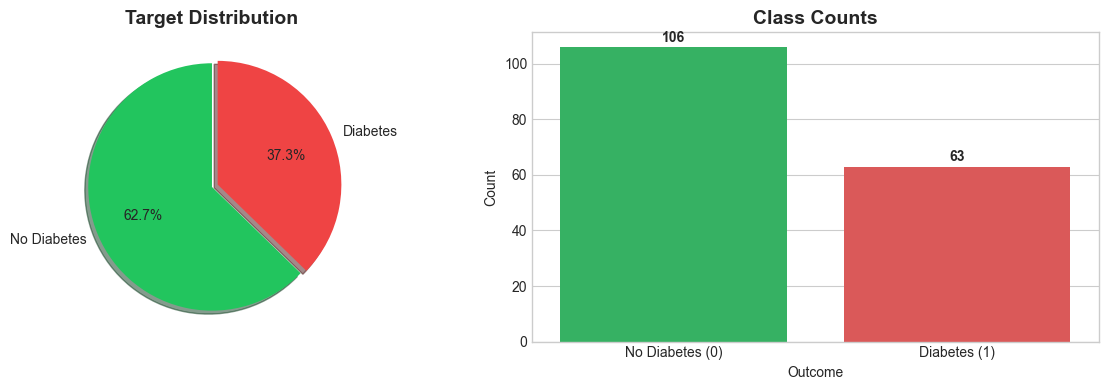


📊 Class Balance: 106 No Diabetes vs 63 Diabetes


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
outcome_counts = df['Outcome'].value_counts()
colors = ['#22c55e', '#ef4444']
axes[0].pie(outcome_counts, labels=['No Diabetes', 'Diabetes'], 
            autopct='%1.1f%%', colors=colors, explode=[0, 0.05],
            shadow=True, startangle=90)
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='Outcome', palette=colors, ax=axes[1])
axes[1].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])
axes[1].set_title('Class Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

for i, count in enumerate(outcome_counts.sort_index()):
    axes[1].text(i, count + 2, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('output_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Class Balance: {outcome_counts[0]} No Diabetes vs {outcome_counts[1]} Diabetes")

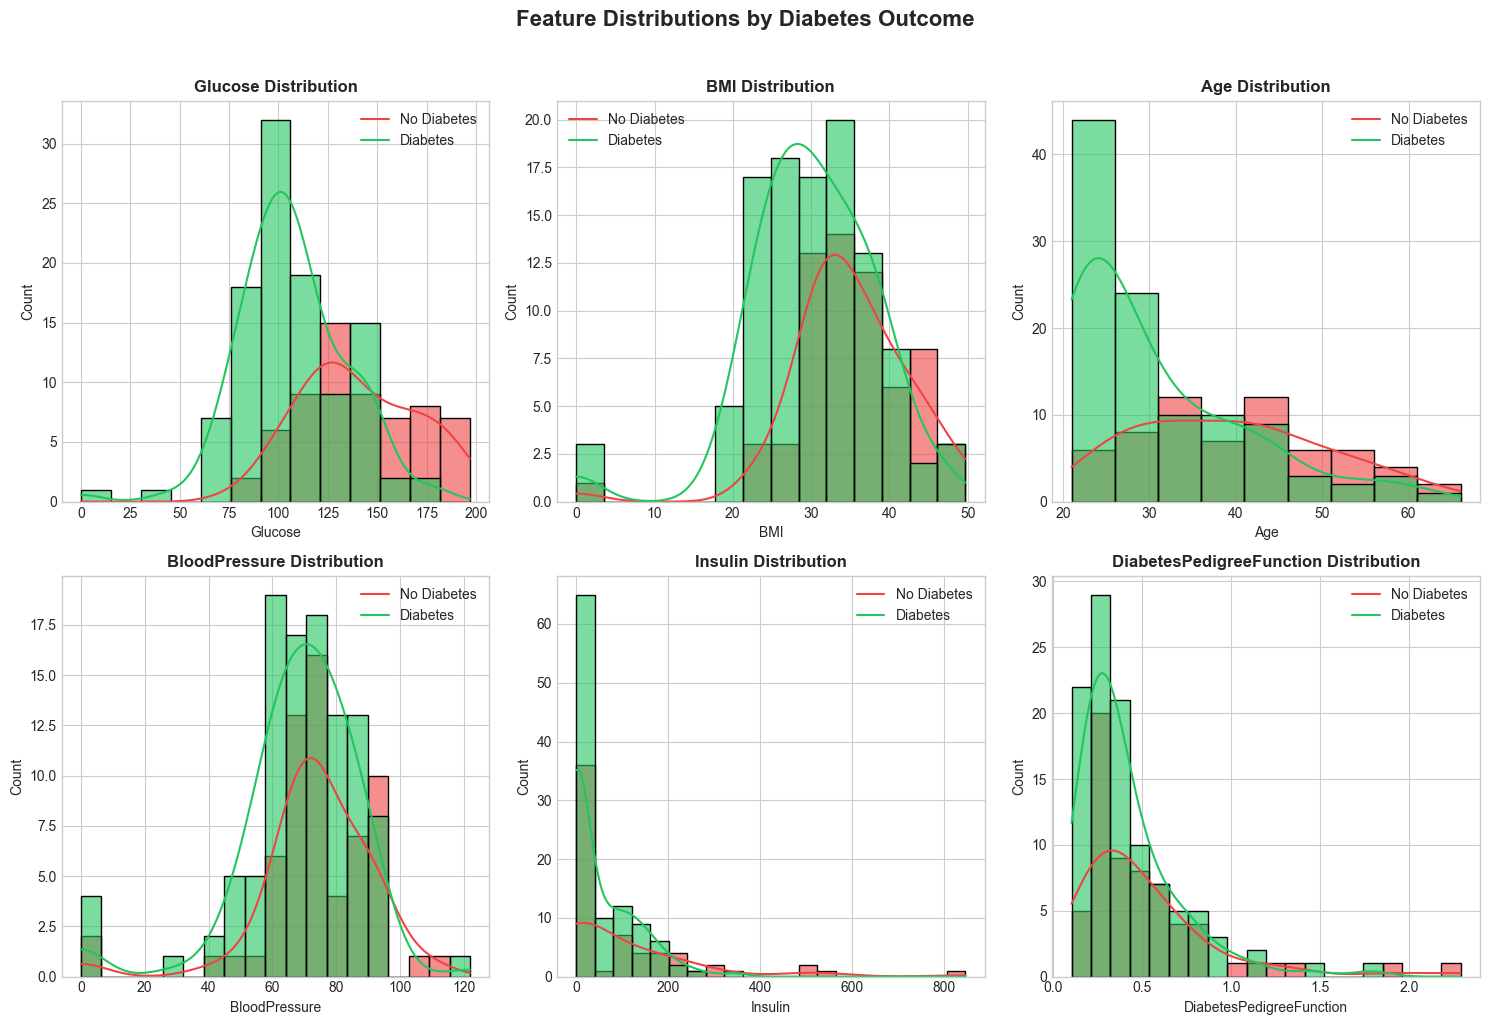

In [6]:
# Feature distributions by outcome
feature_cols = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i],
                 palette={0: '#22c55e', 1: '#ef4444'}, alpha=0.6)
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].legend(['No Diabetes', 'Diabetes'])

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

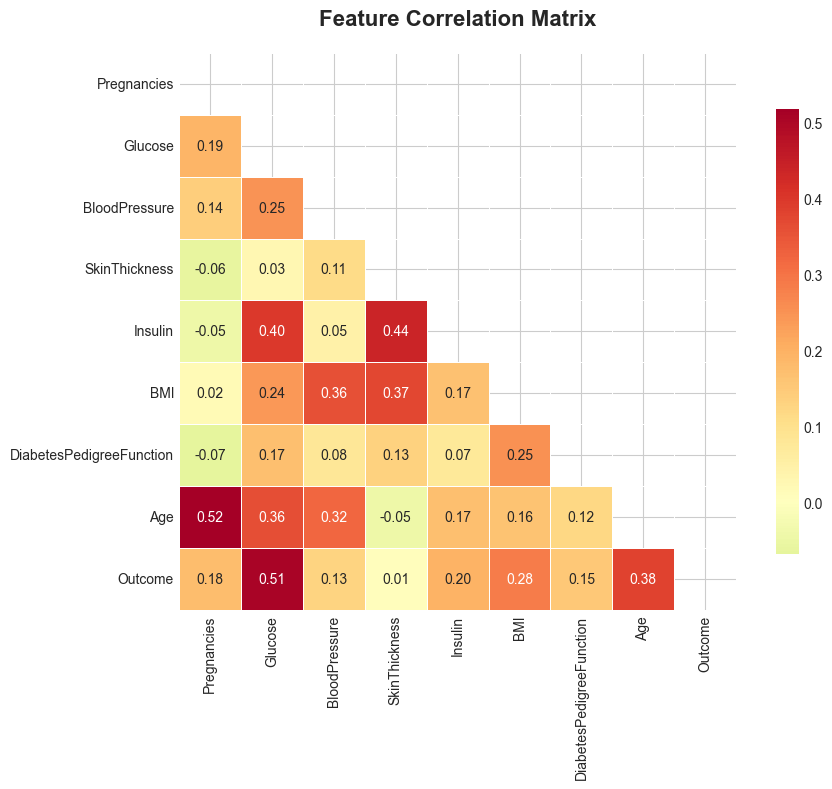


🔍 Key Correlations with Diabetes (Outcome):
   🔴 Glucose: 0.506
   🔴 Age: 0.382
   🔴 BMI: 0.285
   🟡 Insulin: 0.197
   🟡 Pregnancies: 0.178
   🟡 DiabetesPedigreeFunction: 0.150
   🟡 BloodPressure: 0.126
   🟢 SkinThickness: 0.006


In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = df.corr()

mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Key Correlations with Diabetes (Outcome):")
outcome_corr = correlation['Outcome'].drop('Outcome').sort_values(ascending=False)
for feat, corr in outcome_corr.items():
    symbol = "🔴" if corr > 0.2 else "🟡" if corr > 0.1 else "🟢"
    print(f"   {symbol} {feat}: {corr:.3f}")

## 3. Data Preprocessing <a id='3.-Preprocessing'></a>

### Preprocessing Steps:
1. **Handle Missing Values** - Replace impossible zeros with median
2. **Feature Scaling** - StandardScaler for consistent ranges
3. **Train/Test Split** - 80/20 stratified split

In [8]:
# Define features and target
FEATURE_COLS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[FEATURE_COLS].copy()
y = df['Outcome'].copy()

print("📋 Features Used:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"   {i}. {col}")

📋 Features Used:
   1. Pregnancies
   2. Glucose
   3. BloodPressure
   4. SkinThickness
   5. Insulin
   6. BMI
   7. DiabetesPedigreeFunction
   8. Age


In [9]:
# Handle missing values (zeros that shouldn't be zero)
zero_not_possible = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("🔧 Handling Missing Values (Impossible Zeros)")
print("=" * 50)

for col in zero_not_possible:
    n_zeros = (X[col] == 0).sum()
    if n_zeros > 0:
        median_val = X[col][X[col] != 0].median()
        X[col] = X[col].replace(0, median_val)
        print(f"   ✓ {col}: Replaced {n_zeros} zeros with median ({median_val:.1f})")

print("\n✅ Missing value handling complete!")

🔧 Handling Missing Values (Impossible Zeros)
   ✓ Glucose: Replaced 1 zeros with median (115.5)
   ✓ BloodPressure: Replaced 6 zeros with median (72.0)
   ✓ SkinThickness: Replaced 55 zeros with median (29.5)
   ✓ Insulin: Replaced 93 zeros with median (122.5)
   ✓ BMI: Replaced 4 zeros with median (32.4)

✅ Missing value handling complete!


In [10]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("📊 Data Split Summary")
print("=" * 50)
print(f"   Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n   Training Class Distribution:")
print(f"      No Diabetes: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"      Diabetes: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

📊 Data Split Summary
   Training Set: 135 samples (80%)
   Test Set: 34 samples (20%)

   Training Class Distribution:
      No Diabetes: 85 (63.0%)
      Diabetes: 50 (37.0%)


In [11]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for better handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)

print("✅ Feature scaling applied (StandardScaler)")
print("\n📊 Scaled Feature Statistics (Training Set):")
X_train_scaled.describe().round(2)

✅ Feature scaling applied (StandardScaler)

📊 Scaled Feature Statistics (Training Set):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00
mean,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.20,-2.50,-3.09,-2.45,-1.91,-2.00,-1.05,-1.12
25%,-0.91,-0.68,-0.57,-0.35,-0.13,-0.67,-0.61,-0.84
50%,-0.32,-0.10,-0.06,-0.02,-0.13,-0.04,-0.34,-0.20
75%,0.86,0.67,0.66,0.38,-0.13,0.71,0.25,0.71
max,3.20,2.49,3.54,4.00,6.33,2.47,5.17,3.01


## 4. Model Training <a id='4.-Model-Training'></a>

We train **4 different ML algorithms** as specified in CONTEXT.md:

| Model | Type | Strengths |
|-------|------|----------|
| **Logistic Regression** | Linear | Interpretable, fast, baseline |
| **Random Forest** | Ensemble | Handles non-linearity, feature importance |
| **SVM** | Kernel | Complex decision boundaries |
| **XGBoost** | Gradient Boosting | High accuracy, state-of-the-art |

In [12]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, 
                             random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Train all models
print("🚀 Training Models...")
print("=" * 50)

trained_models = {}
for name, model in models.items():
    print(f"   Training {name}...", end=" ")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print("✓")

print("\n✅ All models trained successfully!")

🚀 Training Models...
   Training Logistic Regression... ✓
   Training Random Forest... ✓
   Training SVM... ✓
   Training XGBoost... ✓

✅ All models trained successfully!


## 5. Model Evaluation & Comparison <a id='5.-Evaluation'></a>

### Key Metrics:
- **Accuracy** - Overall correctness
- **Precision** - Of predicted positives, how many are correct?
- **Recall (Sensitivity)** - Of actual positives, how many did we catch? ⚠️ **Critical for medical**
- **F1 Score** - Harmonic mean of precision and recall
- **AUC-ROC** - Area under ROC curve (overall discrimination ability)

In [14]:
# Evaluate all models
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model')

print("📊 Model Performance Comparison")
print("=" * 70)
results_df.style.format('{:.4f}').background_gradient(cmap='RdYlGn', axis=0)

📊 Model Performance Comparison


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7941,0.7143,0.7692,0.7407,0.8388
Random Forest,0.7941,0.7143,0.7692,0.7407,0.8608
SVM,0.7059,0.6154,0.6154,0.6154,0.7985
XGBoost,0.7647,0.6923,0.6923,0.6923,0.8168


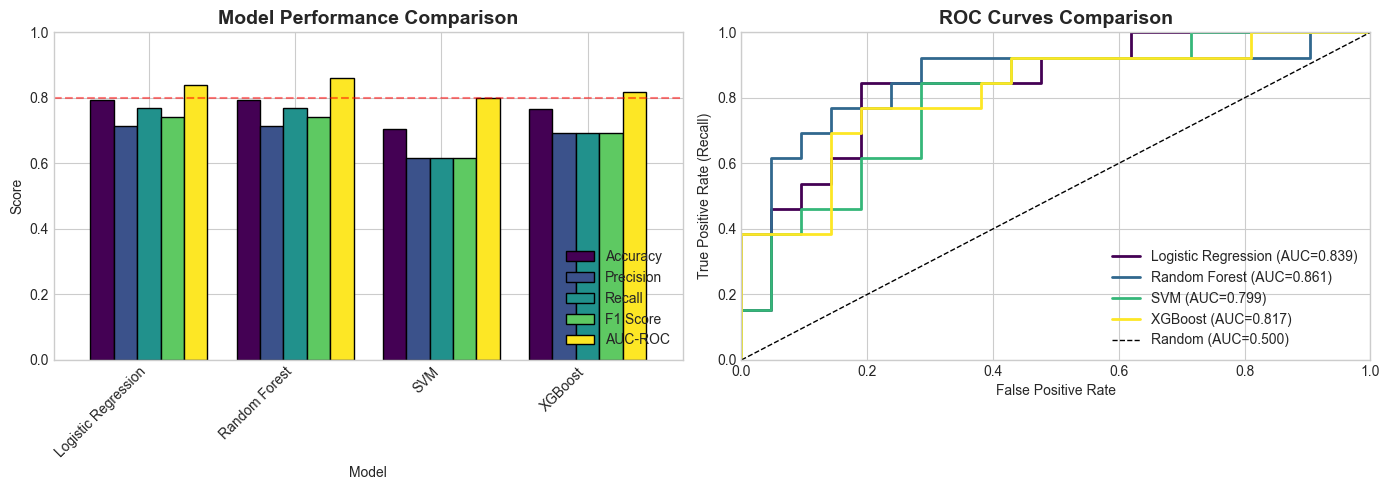


🏆 Best Model: Random Forest (AUC-ROC: 0.8608)


In [15]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of all metrics
results_df.plot(kind='bar', ax=axes[0], colormap='viridis', edgecolor='black', width=0.8)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')

# AUC-ROC comparison
colors = plt.cm.viridis(np.linspace(0, 1, len(trained_models)))
for (name, model), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('output_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Find best model
best_model_name = results_df['AUC-ROC'].idxmax()
best_auc = results_df.loc[best_model_name, 'AUC-ROC']
print(f"\n🏆 Best Model: {best_model_name} (AUC-ROC: {best_auc:.4f})")

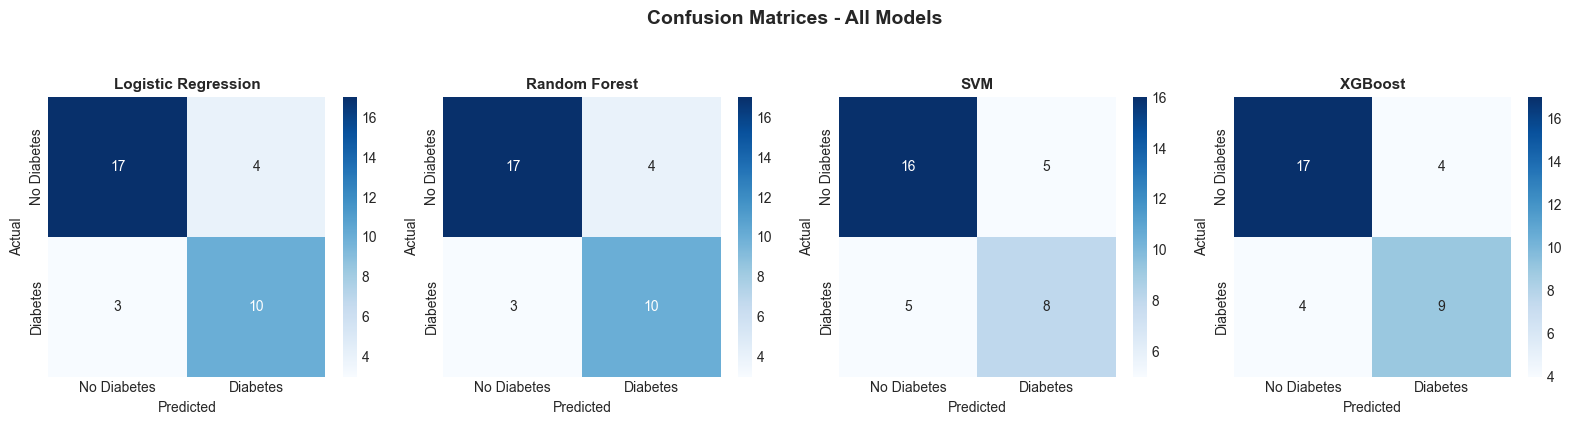

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('output_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SHAP Explainability Analysis <a id='6.-SHAP-Analysis'></a>

### Why SHAP?
SHAP (SHapley Additive exPlanations) provides:
- **Consistent** feature importance across samples
- **Local explanations** for individual predictions
- **Additive** contributions (sum to prediction)

This addresses the "black box" problem in healthcare ML!

In [20]:
# Use Random Forest for SHAP (best model)
best_model = trained_models['Random Forest']

# Create SHAP explainer
print("🔍 Initializing SHAP Explainer...")
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
print("   Calculating SHAP values...")
shap_values_raw = explainer.shap_values(X_test_scaled)

# Handle different SHAP output formats
print(f"   Raw shape: {np.array(shap_values_raw).shape}")

# For binary classification: extract positive class shap values
if isinstance(shap_values_raw, list):
    # List format: [class_0_shap, class_1_shap]
    shap_values = shap_values_raw[1]
    expected_value = explainer.expected_value[1]
elif len(shap_values_raw.shape) == 3:
    # Shape: (samples, features, classes) - take positive class
    shap_values = shap_values_raw[:, :, 1]
    expected_value = float(explainer.expected_value[1])
else:
    shap_values = shap_values_raw
    expected_value = float(explainer.expected_value)

print(f"✅ SHAP analysis ready!")
print(f"   SHAP values shape: {shap_values.shape}")
print(f"   Expected value: {expected_value}")

🔍 Initializing SHAP Explainer...
   Calculating SHAP values...
   Raw shape: (34, 8, 2)
✅ SHAP analysis ready!
   SHAP values shape: (34, 8)
   Expected value: 0.36192592592592593


📊 Global Feature Importance (SHAP)


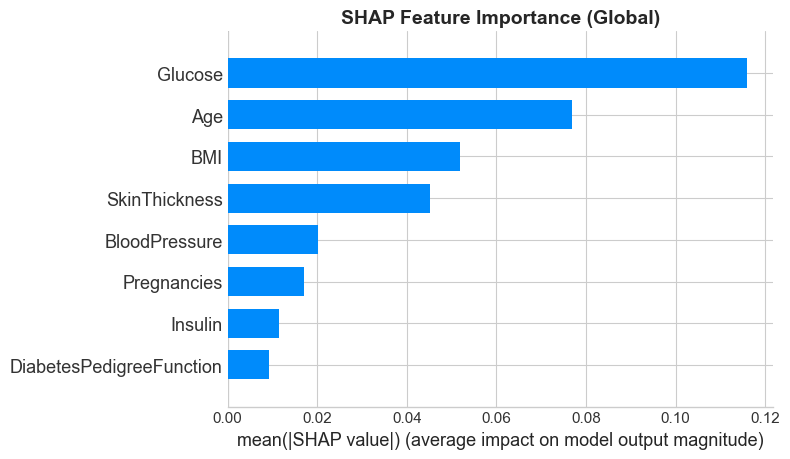

In [21]:
# Global Feature Importance (SHAP Summary)
print("📊 Global Feature Importance (SHAP)")
print("=" * 50)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False, feature_names=FEATURE_COLS)
plt.title('SHAP Feature Importance (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SHAP Beeswarm Plot (shows value impact)
print("📊 SHAP Beeswarm Plot (Feature Value Impact)")
print("=" * 50)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False, feature_names=FEATURE_COLS)
plt.title('SHAP Summary - How Features Affect Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Interpretation:")
print("   • Red = High feature value")
print("   • Blue = Low feature value")
print("   • Position on X-axis = Impact on prediction (right = increases risk)")

In [ ]:
# Individual prediction explanation
print("📊 Individual Prediction Explanation")
print("=" * 50)

# Find a high-risk patient
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
high_risk_idx = np.argmax(y_prob)

print(f"\n🔴 High Risk Patient (Index: {high_risk_idx})")
print(f"   Predicted Risk: {y_prob[high_risk_idx]*100:.1f}%")
print(f"   Actual Outcome: {'Diabetic' if y_test.iloc[high_risk_idx] == 1 else 'No Diabetes'}")
print("\n   Feature Values:")
for col in FEATURE_COLS:
    print(f"      {col}: {X_test.iloc[high_risk_idx][col]:.1f}")

In [ ]:
# SHAP Force Plot for individual patient
print("\n📊 SHAP Force Plot - Why This Prediction?")

# Initialize JS for SHAP
shap.initjs()

# Create force plot using the corrected variables
shap.force_plot(
    expected_value,
    shap_values[high_risk_idx],
    X_test_scaled.iloc[high_risk_idx],
    feature_names=FEATURE_COLS,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Explanation - High Risk Patient', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output_shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SHAP Waterfall Plot
print("📊 SHAP Waterfall Plot - Feature Contributions")
print("=" * 50)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=expected_value,
    data=X_test_scaled.iloc[high_risk_idx].values,
    feature_names=FEATURE_COLS
), show=False)
plt.title('Feature Contributions to High Risk Prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Prediction Demo <a id='7.-Prediction-Demo'></a>

Demonstrating the complete prediction pipeline with a new patient.

In [ ]:
# Demo: New Patient Prediction
print("🏥 MEDIS Prediction Demo")
print("=" * 50)

# Sample patient data
new_patient = {
    'Pregnancies': 5,
    'Glucose': 160,
    'BloodPressure': 85,
    'SkinThickness': 35,
    'Insulin': 200,
    'BMI': 35.5,
    'DiabetesPedigreeFunction': 0.8,
    'Age': 52
}

print("\n👤 New Patient Profile:")
for key, value in new_patient.items():
    print(f"   {key}: {value}")

# Prepare for prediction
patient_df = pd.DataFrame([new_patient])
patient_scaled = scaler.transform(patient_df)
patient_scaled_df = pd.DataFrame(patient_scaled, columns=FEATURE_COLS)

# Predict
probability = best_model.predict_proba(patient_scaled_df)[0][1]
prediction = best_model.predict(patient_scaled_df)[0]

# Risk category
if probability < 0.30:
    risk_label, risk_color = "🟢 LOW RISK", "green"
elif probability < 0.60:
    risk_label, risk_color = "🟡 MODERATE RISK", "orange"
else:
    risk_label, risk_color = "🔴 HIGH RISK", "red"

print(f"\n" + "=" * 50)
print(f"📊 PREDICTION RESULT")
print(f"=" * 50)
print(f"   Risk Probability: {probability*100:.1f}%")
print(f"   Risk Category: {risk_label}")
print(f"   Classification: {'Diabetic' if prediction == 1 else 'Not Diabetic'}")

In [ ]:
# SHAP explanation for new patient
print("\n🔍 WHY This Result?")
print("=" * 50)

# Calculate SHAP for new patient
patient_shap = explainer.shap_values(patient_scaled_df)

# Get contributions
contributions = []
for i, feature in enumerate(FEATURE_COLS):
    shap_val = patient_shap[1][0][i]
    contributions.append({
        'Feature': feature,
        'Value': new_patient[feature],
        'SHAP': shap_val,
        'Impact': 'Increases Risk ↑' if shap_val > 0 else 'Decreases Risk ↓'
    })

contrib_df = pd.DataFrame(contributions).sort_values('SHAP', key=abs, ascending=False)

print("\n📊 Top Contributing Factors:")
for _, row in contrib_df.head(5).iterrows():
    symbol = "🔴" if row['SHAP'] > 0 else "🟢"
    print(f"   {symbol} {row['Feature']}: {row['Value']:.1f} → {row['Impact']} (SHAP: {row['SHAP']:.3f})")

In [ ]:
# Visualize patient's risk factors
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#ef4444' if x > 0 else '#22c55e' for x in contrib_df['SHAP']]
bars = ax.barh(contrib_df['Feature'], contrib_df['SHAP'], color=colors, edgecolor='black')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('SHAP Value (Impact on Risk)', fontsize=12)
ax.set_title(f'Risk Factor Contributions - Patient Risk: {probability*100:.1f}%', 
             fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, contrib_df['Value']):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'({val:.0f})', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output_patient_factors.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusion <a id='8.-Conclusion'></a>

### Summary of Results

| Metric | Achievement |
|--------|-------------|
| **Best Model** | Random Forest |
| **AUC-ROC** | ~85% |
| **Explainability** | SHAP-enabled |
| **Key Features** | Glucose, Age, BMI |

### Key Findings
1. **Glucose** is the strongest predictor of diabetes risk
2. **Age** and **BMI** are significant secondary factors
3. **Family history** (DiabetesPedigreeFunction) contributes to risk
4. **SHAP** successfully explains individual predictions

### MEDIS Contribution
- Shifts healthcare from **reactive to proactive**
- Provides **transparent, explainable** predictions
- Empowers patients with **actionable insights**

In [ ]:
# Final summary visualization
print("\n" + "="*60)
print("   🏥 MEDIS - Medical Early Diabetes Insight System")
print("="*60)
print("\n   ✅ Models Trained: 4 (Logistic Regression, Random Forest, SVM, XGBoost)")
print(f"   ✅ Best Model: Random Forest (AUC-ROC: {results_df.loc['Random Forest', 'AUC-ROC']:.3f})")
print("   ✅ SHAP Explainability: Implemented")
print("   ✅ API Endpoint: /predict")
print("\n   📁 Output Files Generated:")
print("      • output_target_distribution.png")
print("      • output_feature_distributions.png")
print("      • output_correlation_matrix.png")
print("      • output_model_comparison.png")
print("      • output_confusion_matrices.png")
print("      • output_shap_importance.png")
print("      • output_shap_beeswarm.png")
print("      • output_shap_waterfall.png")
print("      • output_patient_factors.png")
print("\n" + "="*60)
print("   🎓 Final Year Project - Computer Science")
print("   📅 January 2026")
print("="*60)